Import Libraries and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import os
import kagglehub

from scipy.signal import butter, filtfilt, find_peaks

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Download and load WESAD dataset

dataset_path = kagglehub.dataset_download(
    "orvile/wesad-wearable-stress-affect-detection-dataset"
)

print("Dataset path:", dataset_path)

subject_path = os.path.join(
    dataset_path,
    "WESAD",
    "S2",
    "S2.pkl"
)

with open(subject_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("Data loaded successfully")

100%|██████████| 2.43G/2.43G [01:33<00:00, 27.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/versions/1
Data loaded successfully


Extract ECG Signal and Labels

In [3]:
# Extract ECG Signal and labels

ecg = data["signal"]["chest"]["ECG"][:, 0]
labels = np.array(data["label"])

print("ECG length:", len(ecg))
print("Labels length:", len(labels))

ECG length: 4255300
Labels length: 4255300


In [4]:
# WESAD labels

# 1 = Baseline
# 2 = Stress
# 3 = Amusement
# 4 = Meditation

baseline_label = 1
stress_label = 2

Visualize Raw ECG Signal

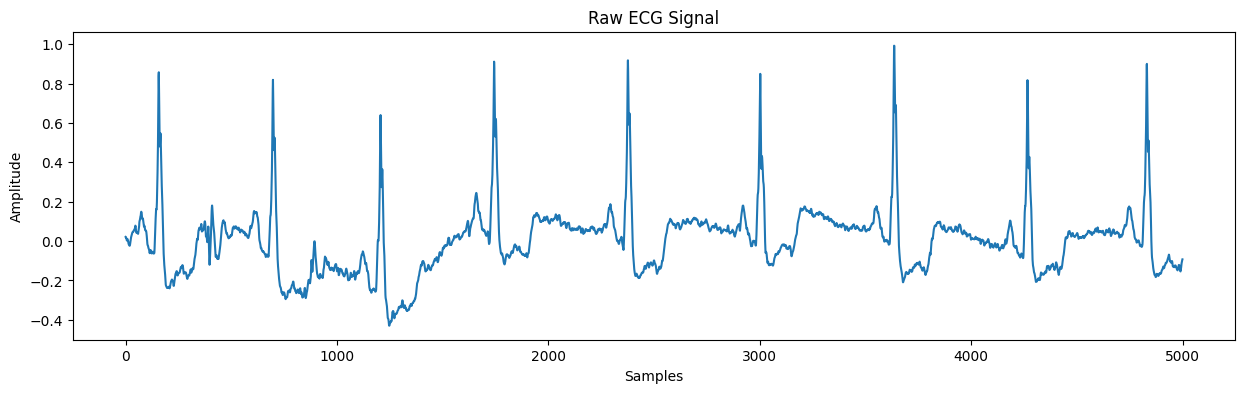

In [5]:
# Raw ECG Signal

plt.figure(figsize=(15,4))

plt.plot(ecg[:5000])

plt.title("Raw ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

ECG Filtering

In [6]:
def bandpass(signal, low=0.5, high=40, fs=700):

    b, a = butter(
        2,
        [low/(fs/2), high/(fs/2)],
        btype="band"
    )

    return filtfilt(b, a, signal)

ecg_filt = bandpass(ecg)

print("Filtering completed")

Filtering completed


Visualize Filtered ECG

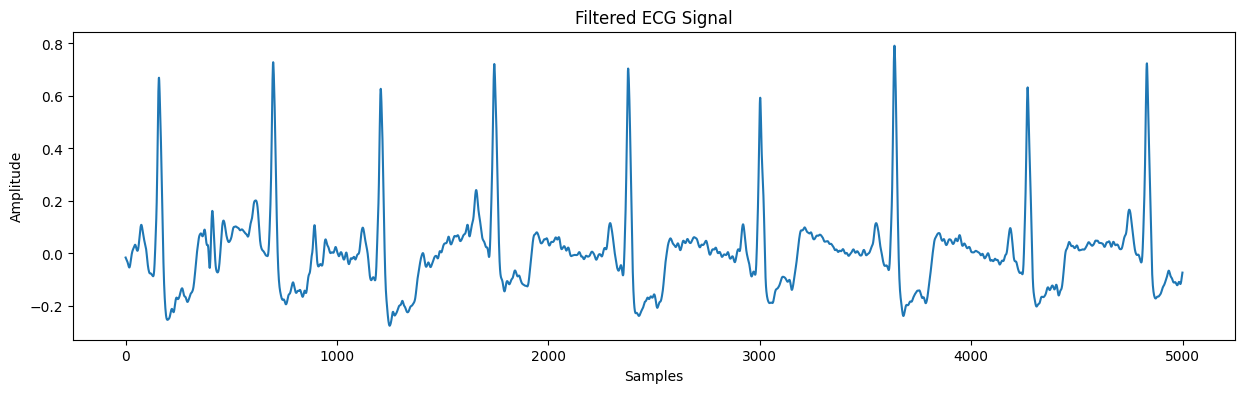

In [7]:
plt.figure(figsize=(15,4))

plt.plot(ecg_filt[:5000])

plt.title("Filtered ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

R-Peak Detection

In [8]:
peaks, _ = find_peaks(
    ecg_filt,
    distance=200
)

print("Detected beats:", len(peaks))

Detected beats: 15760


ECG with Detected R-Peaks

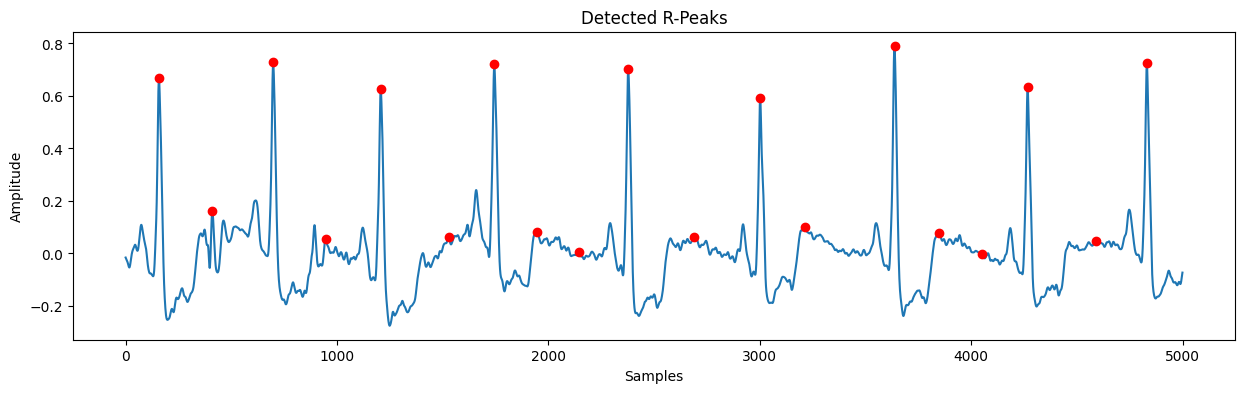

In [9]:
peaks_plot = peaks[peaks < 5000]

plt.figure(figsize=(15,4))

plt.plot(ecg_filt[:5000])

plt.plot(
    peaks_plot,
    ecg_filt[peaks_plot],
    "ro"
)

plt.title("Detected R-Peaks")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

RR Interval Analysis

In [10]:
rr = np.diff(peaks)

print("Number of RR intervals:", len(rr))

Number of RR intervals: 15759


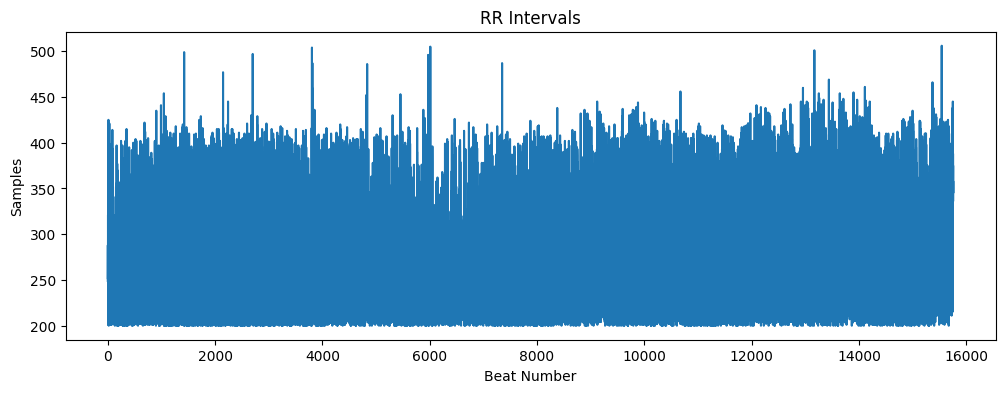

In [11]:
plt.figure(figsize=(12,4))

plt.plot(rr)

plt.title("RR Intervals")
plt.xlabel("Beat Number")
plt.ylabel("Samples")

plt.show()

HRV Feature Extraction

In [12]:
def hrv_features(rr):

    if len(rr) < 5:
        return None

    sdnn = np.std(rr)

    rmssd = np.sqrt(
        np.mean(np.diff(rr)**2)
    )

    mean_rr = np.mean(rr)

    return [sdnn, rmssd, mean_rr]

Create Machine Learning Dataset

In [13]:
window_size = 10000

X = []
y = []

for start in range(
    0,
    len(ecg_filt) - window_size,
    window_size
):

    end = start + window_size

    window_signal = ecg_filt[start:end]
    window_labels = labels[start:end]

    label = np.bincount(
        window_labels
    ).argmax()

    peaks_window, _ = find_peaks(
        window_signal,
        distance=200
    )

    rr_window = np.diff(peaks_window)

    features = hrv_features(rr_window)

    if (
        features is not None
        and label in [baseline_label, stress_label]
    ):

        X.append(features)

        if label == stress_label:
            y.append(1)
        else:
            y.append(0)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (124, 3)


Create DataFrame

In [14]:
df = pd.DataFrame(
    X,
    columns=[
        "SDNN",
        "RMSSD",
        "MeanRR"
    ]
)

df["label"] = y

df.head()

,SDNN,RMSSD,MeanRR,label
0,62.598515,105.133891,259.710526,0
1,41.950559,66.328244,244.725000,0
2,64.615681,103.126398,256.394737,0
3,49.633441,61.482608,264.621622,0
4,57.418026,75.291364,248.794872,0


Statistical Comparison

In [15]:
group_stats = df.groupby("label").mean()

print(group_stats)

            SDNN       RMSSD      MeanRR
label                                   
0      68.682184  114.396996  264.633009
1      60.332755  100.290642  270.463770


SDNN Comparison

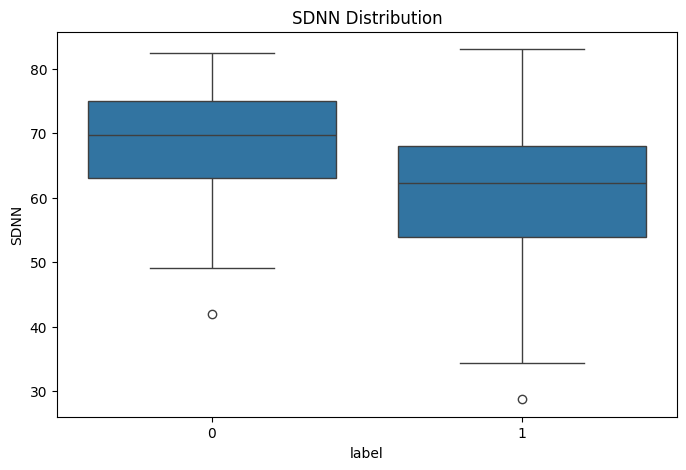

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="SDNN",
    data=df
)

plt.title("SDNN Distribution")

plt.show()

RMSSD Comparison

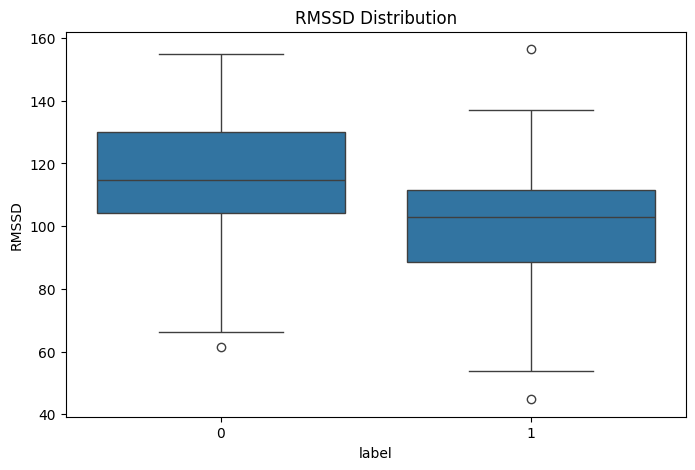

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="RMSSD",
    data=df
)

plt.title("RMSSD Distribution")

plt.show()

Mean RR Comparison

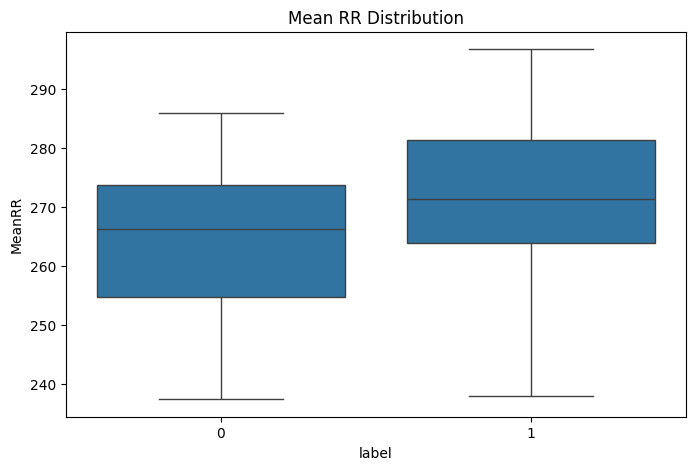

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="MeanRR",
    data=df
)

plt.title("Mean RR Distribution")

plt.show()

Correlation Analysis

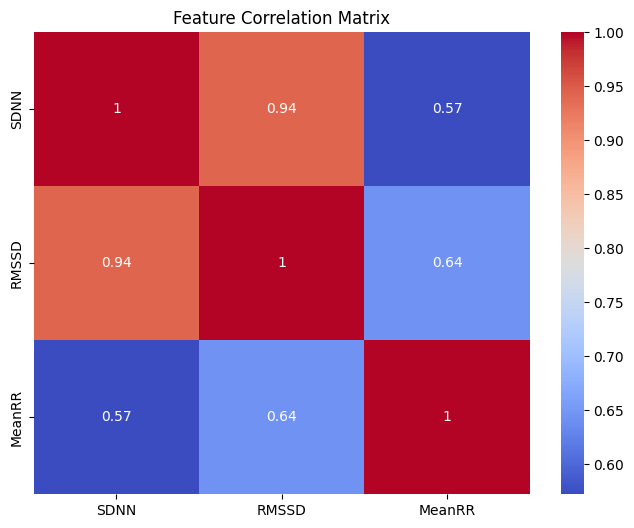

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop(columns=["label"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

Train Random Forest Model

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)

Model Evaluation

In [21]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.78      0.78      0.78         9

    accuracy                           0.84        25
   macro avg       0.83      0.83      0.83        25
weighted avg       0.84      0.84      0.84        25



Confusion Matrix

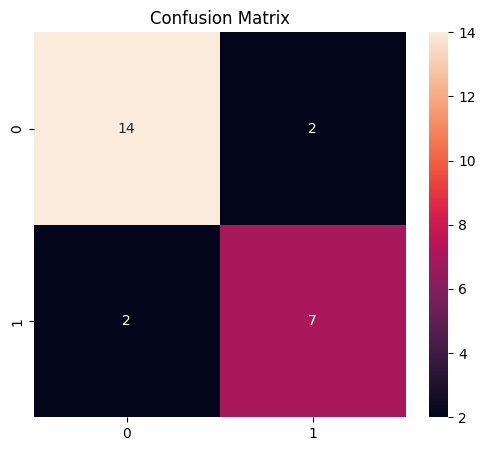

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

Feature Importance

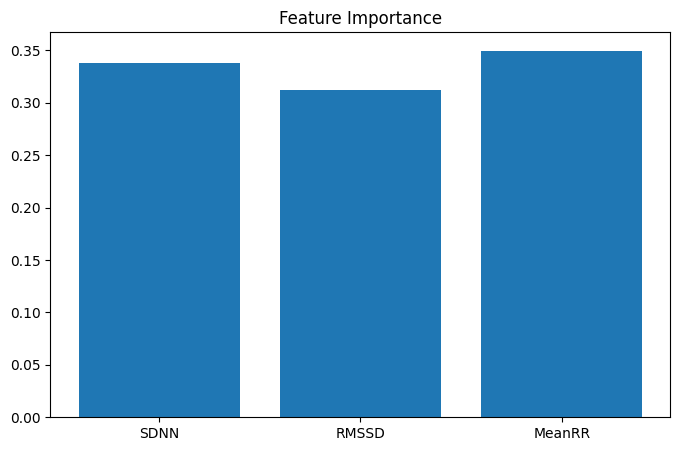

In [23]:
importance = model.feature_importances_

features = [
    "SDNN",
    "RMSSD",
    "MeanRR"
]

plt.figure(figsize=(8,5))

plt.bar(
    features,
    importance
)

plt.title("Feature Importance")

plt.show()

Class Distribution

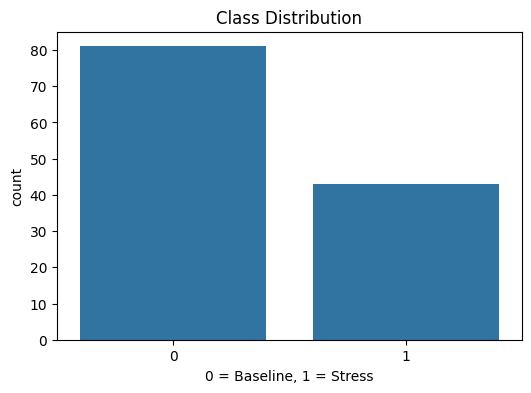

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("0 = Baseline, 1 = Stress")

plt.show()